# Proyek Klasifikasi Gambar: Flower Classification
- **Nama:** Dimas Firmansyah
- **Email:** dimas.frmn012@gmail.com
- **ID Dicoding:** dimas_firmansyah12

## Import Semua Packages/Library yang Digunakan

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import shutil


## Data Preparation

### Data Loading

In [2]:
# Unggah file kaggle.json seperti instruksi sebelumnya
!pip install -q kaggle

import os
os.makedirs("/root/.kaggle", exist_ok=True)

from google.colab import files
uploaded = files.upload()  # Upload kaggle.json di sini

with open("/root/.kaggle/kaggle.json", "wb") as f:
    f.write(uploaded["kaggle.json"])

!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d alxmamaev/flowers-recognition
!unzip -q flowers-recognition.zip -d flowers_dataset


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
 55% 123M/225M [00:00<00:00, 1.29GB/s]
100% 225M/225M [00:00<00:00, 791MB/s] 


### Data Preprocessing

#### Split Dataset

In [3]:
# Install terlebih dahulu jika belum
!pip install split-folders

# Import
import splitfolders

# Split folder ke train/val/test
splitfolders.ratio("/content/flowers_dataset/flowers", output="flowers_split", seed=1337, ratio=(.7, .2, .1))


Copying files: 4317 files [00:01, 2617.76 files/s]


In [4]:
train_dir = "/content/flowers_split/train"
val_dir = "/content/flowers_split/val"
test_dir = "/content/flowers_split/test"

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(150,150), batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(150,150), batch_size=32, class_mode='categorical')
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(150,150), batch_size=32, class_mode='categorical')


Found 3019 images belonging to 5 classes.
Found 860 images belonging to 5 classes.
Found 438 images belonging to 5 classes.


## Modelling

In [6]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.applications import MobileNetV2

# Base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)
base_model.trainable = False  # freeze

# Buat model
model = Sequential([
    InputLayer(shape=(150, 150, 3)),
    base_model,

    # Tambahkan layer Conv2D & Pooling di belakang (tidak merusak input)
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(),

    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(5, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


<ipython-input-6-4110599760>:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,631,525 (10.04 MB)

 Trainable params: 373,541 (1.42 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Simpan model terbaik
checkpoint_cb = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Early stopping juga berdasarkan val_accuracy
earlystop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    mode='max'
)

# Training
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[earlystop_cb, checkpoint_cb]
)


Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9140 - loss: 0.2071
Epoch 1: val_accuracy improved from -inf to 0.83837, saving model to best_model.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9140 - loss: 0.2072 - val_accuracy: 0.8384 - val_loss: 0.7004
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9051 - loss: 0.2519
Epoch 2: val_accuracy did not improve from 0.83837
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9051 - loss: 0.2519 - val_accuracy: 0.8233 - val_loss: 0.7262
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9199 - loss: 0.2130
Epoch 3: val_accuracy did not improve from 0.83837
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.9198 - loss: 0.2130 - val_accuracy: 0.8291 - val_loss: 0.6552
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9183 - loss: 0.2085
Epoch 4: val_accuracy improved from 0.83837 to 0.84186, saving model to best_model.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9182 - loss: 0.2086 - val_accuracy: 0.8419 - val_loss: 0.6398
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9268 - loss: 0.1889
Epoch 5: val_accuracy improved from 0.84186 to 0.84535, saving model to best_model.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.9268 - loss: 0.1889 - val_accuracy: 0.8453 - val_loss: 0.6563
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9287 - loss: 0.1753
Epoch 6: val_accuracy improved from 0.84535 to 0.84767, saving model to best_model.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.9287 - loss: 0.1752 - val_accuracy: 0.8477 - val_loss: 0.6299
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9204 - loss: 0.1947
Epoch 7: val_accuracy improved from 0.84767 to 0.85000, saving model to best_model.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9204 - loss: 0.1946 - val_accuracy: 0.8500 - val_loss: 0.6402
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9272 - loss: 0.1722
Epoch 8: val_accuracy improved from 0.85000 to 0.85116, saving model to best_model.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9272 - loss: 0.1724 - val_accuracy: 0.8512 - val_loss: 0.7184
Epoch 9/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9289 - loss: 0.1932
Epoch 9: val_accuracy did not improve from 0.85116
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9288 - loss: 0.1933 - val_accuracy: 0.8407 - val_loss: 0.6808
Epoch 10/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9308 - loss: 0.1650
Epoch 10: val_accuracy did not improve from 0.85116
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.9308 - loss: 0.1650 - val_accuracy: 0.8500 - val_loss: 0.6241
Epoch 11/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9104 - loss: 0.2045
Epoch 11: val_accuracy improved from 0.85116 to 0.85581, saving model to best_model.h5


95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9105 - loss: 0.2044 - val_accuracy: 0.8558 - val_loss: 0.6333
Epoch 12/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9352 - loss: 0.1638
Epoch 12: val_accuracy did not improve from 0.85581
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9351 - loss: 0.1638 - val_accuracy: 0.8523 - val_loss: 0.7210
Epoch 13/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9250 - loss: 0.1898
Epoch 13: val_accuracy did not improve from 0.85581
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9250 - loss: 0.1897 - val_accuracy: 0.8453 - val_loss: 0.6577
Epoch 14/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9229 - loss: 0.1622
Epoch 14: val_accuracy did not improve from 0.85581
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.9229 - loss: 0.1622 - val_accuracy: 0.8523 - val_loss: 0.6584
Epoch 15/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9339 - loss: 0.1700
Epoch 15: val_accuracy did not impro

## Evaluasi dan Visualisasi

In [23]:
from tensorflow.keras.models import load_model

best_model = load_model('best_model.h5')
loss, acc = best_model.evaluate(test_generator)
print(f"Best model accuracy: {acc*100:.2f}%")


14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.8674 - loss: 0.6373
Best model accuracy: 85.84%


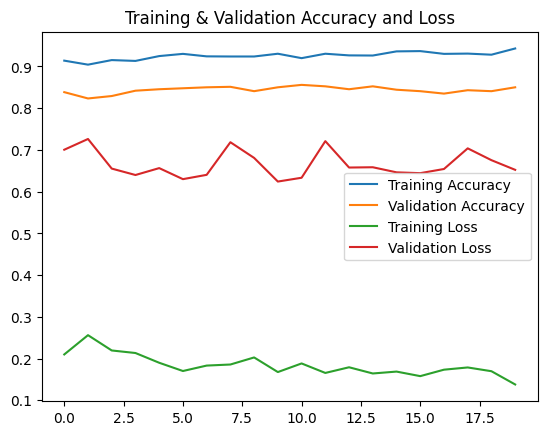

In [24]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training & Validation Accuracy and Loss")
plt.show()


## Konversi Model

In [5]:
from tensorflow.keras.models import load_model
import tensorflow as tf

# Load best model
model = load_model('best_model.h5')

# Simpan juga ke format SavedModel
tf.saved_model.save(model, "saved_model")  # Folder "saved_model" akan dibuat

# Konversi ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model TFLite
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

# Simpan label kelas
labels = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
with open("label.txt", "w") as f:
    for label in labels:
        f.write(f"{label}\n")


Saved artifact at '/tmp/tmpkkoje0k2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  139076415728400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139076415729168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139076415729552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139076415729360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139076415727248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139076415730704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139076415731088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139076415731472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139076415731280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139076415728208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1390764157326

In [25]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.4.3 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.34.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [7]:
# Buat folder tujuan
!mkdir -p tfjs_model

# Konversi model .h5 ke TensorFlow.js format
!tensorflowjs_converter --input_format=keras best_model.h5 tfjs_model/


2025-06-13 04:31:27.446036: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749789087.481215   11462 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749789087.496875   11462 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
failed to lookup keras version from the file,
    this is likely a weight only file


## Inference (Optional)

Saving sun.jpeg to sun.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


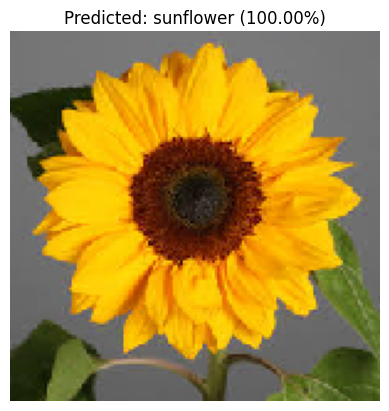

Hasil prediksi: sunflower dengan keyakinan 100.00%


In [9]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import files

# Ambil label kelas dari folder train (filter hanya folder)
class_labels = sorted([
    d for d in os.listdir("flowers_split/train")
    if os.path.isdir(os.path.join("flowers_split/train", d))
])

# Upload file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load & preprocessing gambar
img = image.load_img(filename, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Pastikan model sudah dimuat
try:
    model
except NameError:
    from tensorflow.keras.models import load_model
    model = load_model("model.h5")

# Prediksi
prediction = model.predict(img_array)[0]
predicted_index = np.argmax(prediction)
predicted_class = class_labels[predicted_index]
confidence = prediction[predicted_index] * 100

# Tampilkan hasil
plt.imshow(img)
plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"Hasil prediksi: {predicted_class} dengan keyakinan {confidence:.2f}%")
